# Preprocesamiento de Datos - SARFIRE-GIF

## Objetivos del Preprocesamiento

Este notebook prepara los datos para el modelado de Grandes Incendios Forestales (GIF) en España.

**Objetivos específicos:**
- Filtrar datos temporales (excluir años incompletos 2021-2023)
- Realizar merge entre datasets de incendios y FWI mediante geocodificación
- Crear features temporales y geográficas
- Preparar variable objetivo (GIF: superficie > 500 ha)
- Realizar split temporal para train/test

## Decisiones Basadas en EDA

Basándonos en los hallazgos del EDA (`01_EDA.ipynb`):

1. **Filtrado temporal:** Excluir años 2021-2023 (datos incompletos)
2. **Merge FWI:** Asignar provincia a coordenadas FWI usando distancia euclidiana
3. **Desbalanceo:** 146:1 (No-GIF:GIF) - se manejará en modelado
4. **Coordenadas faltantes:** 18.6% sin coordenadas - se mantienen usando idprovincia

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Librerías importadas correctamente")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")

✅ Librerías importadas correctamente
📊 Pandas version: 3.0.0
🔢 NumPy version: 2.3.5


## 2. CARGA DE DATOS

Cargamos ambos datasets desde los archivos CSV ubicados en `data/raw/`.

In [2]:
# Definir rutas de los archivos
data_dir = Path('../data/raw')
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

incendios_path = data_dir / 'incendios_1968_2023.csv'
fwi_path = data_dir / 'fwi_historico.csv'

# Verificar que los archivos existen
if not incendios_path.exists():
    raise FileNotFoundError(f"❌ No se encontró el archivo: {incendios_path}")
if not fwi_path.exists():
    raise FileNotFoundError(f"❌ No se encontró el archivo: {fwi_path}")

print("✅ Archivos encontrados")
print(f"📁 Incendios: {incendios_path}")
print(f"📁 FWI: {fwi_path}")
print(f"📁 Directorio procesado: {processed_dir}")

✅ Archivos encontrados
📁 Incendios: ../data/raw/incendios_1968_2023.csv
📁 FWI: ../data/raw/fwi_historico.csv
📁 Directorio procesado: ../data/processed


In [3]:
# Cargar dataset de incendios
print("📥 Cargando dataset de incendios...")
df_incendios = pd.read_csv(incendios_path, low_memory=False)
print(f"✅ Dataset de incendios cargado: {len(df_incendios):,} registros")

# Parsear fecha en dataset de incendios
if 'fecha' in df_incendios.columns:
    df_incendios['fecha'] = pd.to_datetime(df_incendios['fecha'], errors='coerce')
    print(f"✅ Columna 'fecha' parseada a datetime")

# Cargar dataset FWI (puede tardar debido al tamaño)
print("\n📥 Cargando dataset FWI...")
df_fwi = pd.read_csv(fwi_path, low_memory=False)
print(f"✅ Dataset FWI cargado: {len(df_fwi):,} registros")

# Parsear fecha en dataset FWI
if 'date' in df_fwi.columns:
    df_fwi['date'] = pd.to_datetime(df_fwi['date'], errors='coerce')
    print(f"✅ Columna 'date' parseada a datetime")

# Mostrar información básica
print(f"\n📊 Shape incendios: {df_incendios.shape}")
print(f"📊 Shape FWI: {df_fwi.shape}")

📥 Cargando dataset de incendios...
✅ Dataset de incendios cargado: 292,181 registros
✅ Columna 'fecha' parseada a datetime

📥 Cargando dataset FWI...
✅ Dataset FWI cargado: 19,296,888 registros
✅ Columna 'date' parseada a datetime

📊 Shape incendios: (292181, 21)
📊 Shape FWI: (19296888, 4)


## 3. FILTRADO TEMPORAL

Filtramos los datos para excluir los años 2021-2023 que están incompletos según el EDA.

In [4]:
# Estadísticas antes del filtrado
print("=" * 80)
print("ESTADÍSTICAS ANTES DEL FILTRADO TEMPORAL")
print("=" * 80)

print(f"\n📅 Rango de fechas - Incendios:")
print(f"   Desde: {df_incendios['fecha'].min()}")
print(f"   Hasta: {df_incendios['fecha'].max()}")

print(f"\n📅 Rango de fechas - FWI:")
print(f"   Desde: {df_fwi['date'].min()}")
print(f"   Hasta: {df_fwi['date'].max()}")

# Contar registros por año antes del filtrado
print(f"\n📊 Registros por año - Incendios:")
incendios_por_año_antes = df_incendios['fecha'].dt.year.value_counts().sort_index()
print(incendios_por_año_antes.tail(10))

print(f"\n📊 Registros por año - FWI:")
fwi_por_año_antes = df_fwi['date'].dt.year.value_counts().sort_index()
print(fwi_por_año_antes.tail(10))

ESTADÍSTICAS ANTES DEL FILTRADO TEMPORAL

📅 Rango de fechas - Incendios:
   Desde: 1968-01-01 00:00:00
   Hasta: 2023-12-08 00:00:00

📅 Rango de fechas - FWI:
   Desde: 1971-01-01 00:00:00
   Hasta: 2022-12-31 00:00:00

📊 Registros por año - Incendios:
fecha
2014    3196
2015    4125
2016    2432
2017    5223
2018    2004
2019    3796
2020    2287
2021     888
2022     226
2023      23
Name: count, dtype: int64

📊 Registros por año - FWI:
date
2013    370840
2014    370840
2015    370840
2016    371856
2017    370840
2018    370840
2019    370840
2020    371856
2021    370840
2022    370840
Name: count, dtype: int64


In [5]:
# Filtrar incendios: 1968-2020 (excluir 2021-2023)
print("\n" + "=" * 80)
print("FILTRADO TEMPORAL: 1968-2020")
print("=" * 80)

df_incendios_filtrado = df_incendios[
    (df_incendios['fecha'].dt.year >= 1968) & 
    (df_incendios['fecha'].dt.year <= 2020)
].copy()

df_fwi_filtrado = df_fwi[
    (df_fwi['date'].dt.year >= 1968) & 
    (df_fwi['date'].dt.year <= 2020)
].copy()

print(f"\n✅ Incendios filtrados:")
print(f"   Antes: {len(df_incendios):,} registros")
print(f"   Después: {len(df_incendios_filtrado):,} registros")
print(f"   Eliminados: {len(df_incendios) - len(df_incendios_filtrado):,} registros ({100*(len(df_incendios) - len(df_incendios_filtrado))/len(df_incendios):.1f}%)")

print(f"\n✅ FWI filtrado:")
print(f"   Antes: {len(df_fwi):,} registros")
print(f"   Después: {len(df_fwi_filtrado):,} registros")
print(f"   Eliminados: {len(df_fwi) - len(df_fwi_filtrado):,} registros ({100*(len(df_fwi) - len(df_fwi_filtrado))/len(df_fwi):.1f}%)")

# Actualizar referencias
df_incendios = df_incendios_filtrado
df_fwi = df_fwi_filtrado


FILTRADO TEMPORAL: 1968-2020

✅ Incendios filtrados:
   Antes: 292,181 registros
   Después: 291,044 registros
   Eliminados: 1,137 registros (0.4%)

✅ FWI filtrado:
   Antes: 19,296,888 registros
   Después: 18,555,208 registros
   Eliminados: 741,680 registros (3.8%)


## 4. MERGE FWI - OPCIÓN A (CRÍTICO)

Implementamos la estrategia de merge FWI mediante geocodificación:

**A)** Asignar provincia a cada coordenada FWI usando distancia euclidiana  
**B)** Agregar FWI por (fecha, provincia)  
**C)** Join con incendios por (fecha, provincia)

In [6]:
# Diccionario de provincias españolas con coordenadas aproximadas (centroides)
# Formato: {idprovincia: (longitud, latitud)}
PROVINCIAS_COORDENADAS = {
    1: (-2.68, 42.85),   # Álava
    2: (-1.86, 38.99),   # Albacete
    3: (-0.49, 38.54),   # Alicante
    4: (-2.45, 36.84),   # Almería
    5: (-4.70, 40.66),   # Ávila
    6: (-6.98, 38.88),   # Badajoz
    7: (2.65, 39.57),    # Baleares
    8: (2.17, 41.39),    # Barcelona
    9: (-3.68, 42.34),   # Burgos
    10: (-6.37, 39.48),  # Cáceres
    11: (-5.45, 36.53),  # Cádiz
    12: (-0.38, 39.99),  # Castellón
    13: (-3.93, 39.20),  # Ciudad Real
    14: (-4.78, 37.88),  # Córdoba
    15: (-8.54, 43.36),  # A Coruña
    16: (-2.13, 39.46),  # Cuenca
    17: (2.82, 41.99),   # Girona
    18: (-3.60, 37.18),  # Granada
    19: (-3.18, 40.63),  # Guadalajara
    20: (-2.32, 43.32),  # Gipuzkoa
    21: (-6.95, 37.26),  # Huelva
    22: (-0.89, 42.13),  # Huesca
    23: (-3.77, 38.00),  # Jaén
    24: (-5.57, 42.60),  # León
    25: (0.62, 41.61),   # Lleida
    26: (-2.45, 42.47),  # La Rioja
    27: (-7.87, 43.01),  # Lugo
    28: (-3.68, 40.42),  # Madrid
    29: (-4.42, 36.72),  # Málaga
    30: (-1.13, 37.99),  # Murcia
    31: (-1.65, 42.82),  # Navarra
    32: (-7.87, 42.34),  # Ourense
    33: (-5.86, 43.36),  # Asturias
    34: (-4.73, 42.01),  # Palencia
    35: (-15.60, 28.12), # Las Palmas
    36: (-8.63, 42.24),  # Pontevedra
    37: (-5.57, 40.97),  # Salamanca
    38: (-16.25, 28.50), # Santa Cruz de Tenerife
    39: (-4.05, 43.36),  # Cantabria
    40: (-4.11, 41.00),  # Segovia
    41: (-5.99, 37.38),  # Sevilla
    42: (-2.46, 41.77),  # Soria
    43: (1.25, 41.12),   # Tarragona
    44: (-1.11, 40.34),  # Teruel
    45: (-4.83, 39.86),  # Toledo
    46: (-0.38, 39.47),  # Valencia
    47: (-4.73, 41.65),  # Valladolid
    48: (-2.67, 43.26),  # Bizkaia
    49: (-5.75, 41.65),  # Zamora
    50: (-1.00, 41.66),  # Zaragoza
    51: (-5.31, 35.89),  # Ceuta (aproximado)
    52: (-2.94, 35.29),  # Melilla (aproximado)
}

print(f"✅ Diccionario de provincias cargado: {len(PROVINCIAS_COORDENADAS)} provincias")

✅ Diccionario de provincias cargado: 52 provincias


In [7]:
# Función para asignar provincia a coordenadas FWI usando distancia euclidiana
def asignar_provincia_a_coordenadas(x, y, provincias_coords):
    """
    Asigna la provincia más cercana a una coordenada (x, y) usando distancia euclidiana.
    
    Parámetros:
    -----------
    x : float
        Longitud
    y : float
        Latitud
    provincias_coords : dict
        Diccionario {idprovincia: (longitud, latitud)}
    
    Retorna:
    --------
    int : idprovincia de la provincia más cercana
    """
    if pd.isna(x) or pd.isna(y):
        return None
    
    min_dist = float('inf')
    provincia_cercana = None
    
    for idprov, (lon_prov, lat_prov) in provincias_coords.items():
        # Distancia euclidiana simple
        dist = np.sqrt((x - lon_prov)**2 + (y - lat_prov)**2)
        if dist < min_dist:
            min_dist = dist
            provincia_cercana = idprov
    
    return provincia_cercana

print("✅ Función de asignación de provincia creada")

✅ Función de asignación de provincia creada


In [8]:
# A) Asignar provincia a cada coordenada FWI
print("=" * 80)
print("PASO A: ASIGNAR PROVINCIA A COORDENADAS FWI")
print("=" * 80)

# Obtener coordenadas únicas para optimizar el proceso
coordenadas_unicas = df_fwi[['x', 'y']].drop_duplicates()
print(f"\n📊 Coordenadas únicas en FWI: {len(coordenadas_unicas):,}")

# Aplicar función de asignación (esto puede tardar)
print("\n🔄 Asignando provincias a coordenadas...")
coordenadas_unicas['idprovincia'] = coordenadas_unicas.apply(
    lambda row: asignar_provincia_a_coordenadas(row['x'], row['y'], PROVINCIAS_COORDENADAS),
    axis=1
)

# Merge de vuelta al dataset FWI completo
df_fwi = df_fwi.merge(coordenadas_unicas[['x', 'y', 'idprovincia']], on=['x', 'y'], how='left')

print(f"✅ Provincias asignadas")
print(f"   Registros con provincia asignada: {df_fwi['idprovincia'].notna().sum():,} ({100*df_fwi['idprovincia'].notna().sum()/len(df_fwi):.1f}%)")
print(f"   Registros sin provincia: {df_fwi['idprovincia'].isna().sum():,} ({100*df_fwi['idprovincia'].isna().sum()/len(df_fwi):.1f}%)")

# Mostrar distribución de provincias asignadas
if df_fwi['idprovincia'].notna().sum() > 0:
    print(f"\n📊 Top 10 provincias más frecuentes en FWI:")
    print(df_fwi['idprovincia'].value_counts().head(10))

PASO A: ASIGNAR PROVINCIA A COORDENADAS FWI

📊 Coordenadas únicas en FWI: 1,016

🔄 Asignando provincias a coordenadas...
✅ Provincias asignadas
   Registros con provincia asignada: 18,555,208 (100.0%)
   Registros sin provincia: 0 (0.0%)

📊 Top 10 provincias más frecuentes en FWI:
idprovincia
25    785309
10    657468
14    529627
13    511364
7     493101
2     493101
42    474838
44    474838
23    474838
27    456575
Name: count, dtype: int64


In [9]:
# B) Agregar FWI por (fecha, provincia)
print("\n" + "=" * 80)
print("PASO B: AGREGAR FWI POR (FECHA, PROVINCIA)")
print("=" * 80)

# Filtrar solo registros con provincia asignada
df_fwi_con_provincia = df_fwi[df_fwi['idprovincia'].notna()].copy()

print(f"\n📊 Registros FWI con provincia: {len(df_fwi_con_provincia):,}")

# Agregar por (date, idprovincia)
print("\n🔄 Agregando FWI por (fecha, provincia)...")
df_fwi_agregado = df_fwi_con_provincia.groupby(['date', 'idprovincia']).agg({
    'fwi': ['mean', 'max', lambda x: x.quantile(0.90)]  # fwi_mean, fwi_max, fwi_p90
}).reset_index()

# Aplanar nombres de columnas
df_fwi_agregado.columns = ['date', 'idprovincia', 'fwi_mean', 'fwi_max', 'fwi_p90']
df_fwi_agregado['idprovincia'] = df_fwi_agregado['idprovincia'].astype(int)

print(f"✅ FWI agregado")
print(f"   Registros antes: {len(df_fwi_con_provincia):,}")
print(f"   Registros después: {len(df_fwi_agregado):,}")
print(f"   Reducción: {100*(1 - len(df_fwi_agregado)/len(df_fwi_con_provincia)):.1f}%")

# Mostrar estadísticas
print(f"\n📊 Estadísticas de FWI agregado:")
print(df_fwi_agregado[['fwi_mean', 'fwi_max', 'fwi_p90']].describe())


PASO B: AGREGAR FWI POR (FECHA, PROVINCIA)

📊 Registros FWI con provincia: 18,555,208

🔄 Agregando FWI por (fecha, provincia)...
✅ FWI agregado
   Registros antes: 18,555,208
   Registros después: 949,676
   Reducción: 94.9%

📊 Estadísticas de FWI agregado:
       fwi_mean   fwi_max   fwi_p90
count 949676.00 949676.00 949676.00
mean      12.28     18.92     16.69
std       13.76     18.13     16.85
min        0.00      0.00      0.00
25%        1.27      3.31      2.43
50%        6.63     12.77     10.44
75%       19.75     31.92     28.14
max      102.79    119.77    116.99


In [10]:
# C) Join con incendios por (fecha, provincia)
print("\n" + "=" * 80)
print("PASO C: JOIN CON INCENDIOS")
print("=" * 80)

# Preparar columnas de fecha para el merge
df_incendios['fecha_date'] = df_incendios['fecha'].dt.date
df_fwi_agregado['date_date'] = df_fwi_agregado['date'].dt.date

print(f"\n📊 Registros antes del merge:")
print(f"   Incendios: {len(df_incendios):,}")
print(f"   FWI agregado: {len(df_fwi_agregado):,}")

# Left join (mantener todos los incendios)
print("\n🔄 Realizando merge...")
df_merged = df_incendios.merge(
    df_fwi_agregado,
    left_on=['fecha_date', 'idprovincia'],
    right_on=['date_date', 'idprovincia'],
    how='left'
)

print(f"✅ Merge completado")
print(f"   Registros después del merge: {len(df_merged):,}")

# Estadísticas de nulos FWI
print(f"\n📊 Registros con FWI asignado:")
print(f"   Con FWI: {df_merged['fwi_mean'].notna().sum():,} ({100*df_merged['fwi_mean'].notna().sum()/len(df_merged):.1f}%)")
print(f"   Sin FWI: {df_merged['fwi_mean'].isna().sum():,} ({100*df_merged['fwi_mean'].isna().sum()/len(df_merged):.1f}%)")


PASO C: JOIN CON INCENDIOS

📊 Registros antes del merge:
   Incendios: 291,044
   FWI agregado: 949,676

🔄 Realizando merge...
✅ Merge completado
   Registros después del merge: 291,044

📊 Registros con FWI asignado:
   Con FWI: 286,134 (98.3%)
   Sin FWI: 4,910 (1.7%)


In [11]:
# Imputar nulos FWI con media provincial/mensual
print("\n" + "=" * 80)
print("IMPUTACIÓN DE VALORES NULOS FWI")
print("=" * 80)

# Crear columnas auxiliares para imputación
df_merged['mes'] = df_merged['fecha'].dt.month
df_merged['año'] = df_merged['fecha'].dt.year

# Calcular medias provinciales y mensuales
print("\n🔄 Calculando medias para imputación...")

# Media provincial (todos los meses)
media_provincial = df_merged.groupby('idprovincia')['fwi_mean'].mean()

# Media mensual por provincia
media_mensual_provincial = df_merged.groupby(['idprovincia', 'mes'])['fwi_mean'].mean()

# Media mensual global (fallback)
media_mensual_global = df_merged.groupby('mes')['fwi_mean'].mean()

# Media global (último fallback)
media_global = df_merged['fwi_mean'].mean()

print(f"✅ Medias calculadas")
print(f"   Media global FWI: {media_global:.2f}")

# Imputar valores nulos usando operaciones vectorizadas (más eficiente)
print("\n🔄 Imputando valores nulos...")

# Crear diccionarios para mapeo rápido
dict_mensual_provincial = {(row['idprovincia'], row['mes']): row['fwi_mean'] 
                           for _, row in media_mensual_provincial.reset_index().iterrows()}
dict_provincial = media_provincial.to_dict()
dict_mensual_global = media_mensual_global.to_dict()

# Función auxiliar para imputar fwi_mean
def imputar_fwi_mean(row):
    if pd.notna(row['fwi_mean']):
        return row['fwi_mean']
    # Intentar media mensual por provincia
    key = (row['idprovincia'], row['mes'])
    if key in dict_mensual_provincial:
        return dict_mensual_provincial[key]
    # Intentar media provincial
    if row['idprovincia'] in dict_provincial:
        return dict_provincial[row['idprovincia']]
    # Intentar media mensual global
    if row['mes'] in dict_mensual_global:
        return dict_mensual_global[row['mes']]
    # Último recurso: media global
    return media_global

# Aplicar imputación
df_merged['fwi_mean'] = df_merged.apply(imputar_fwi_mean, axis=1)

# Calcular medias para fwi_max y fwi_p90
media_provincial_max = df_merged.groupby('idprovincia')['fwi_max'].mean()
media_provincial_p90 = df_merged.groupby('idprovincia')['fwi_p90'].mean()
media_mensual_provincial_max = df_merged.groupby(['idprovincia', 'mes'])['fwi_max'].mean()
media_mensual_provincial_p90 = df_merged.groupby(['idprovincia', 'mes'])['fwi_p90'].mean()
media_mensual_global_max = df_merged.groupby('mes')['fwi_max'].mean()
media_mensual_global_p90 = df_merged.groupby('mes')['fwi_p90'].mean()
media_global_max = df_merged['fwi_max'].mean()
media_global_p90 = df_merged['fwi_p90'].mean()

# Imputar fwi_max y fwi_p90 usando fillna con transform (más eficiente)
# Estrategia: mensual por provincia -> provincial -> mensual global -> global
df_merged['fwi_max'] = df_merged['fwi_max'].fillna(
    df_merged.groupby(['idprovincia', 'mes'])['fwi_max'].transform('mean')
).fillna(
    df_merged.groupby('idprovincia')['fwi_max'].transform('mean')
).fillna(
    df_merged.groupby('mes')['fwi_max'].transform('mean')
).fillna(media_global_max)

df_merged['fwi_p90'] = df_merged['fwi_p90'].fillna(
    df_merged.groupby(['idprovincia', 'mes'])['fwi_p90'].transform('mean')
).fillna(
    df_merged.groupby('idprovincia')['fwi_p90'].transform('mean')
).fillna(
    df_merged.groupby('mes')['fwi_p90'].transform('mean')
).fillna(media_global_p90)

print(f"✅ Imputación completada")
print(f"   Registros con FWI después de imputación: {df_merged['fwi_mean'].notna().sum():,} ({100*df_merged['fwi_mean'].notna().sum()/len(df_merged):.1f}%)")

# Limpiar columnas auxiliares temporales
df_merged = df_merged.drop(columns=['fecha_date', 'date_date', 'date'])


IMPUTACIÓN DE VALORES NULOS FWI

🔄 Calculando medias para imputación...
✅ Medias calculadas
   Media global FWI: 18.95

🔄 Imputando valores nulos...
✅ Imputación completada
   Registros con FWI después de imputación: 291,044 (100.0%)


## 5. FEATURE ENGINEERING TEMPORAL

Creamos features temporales que capturan patrones estacionales y semanales.

In [12]:
# Feature engineering temporal
print("=" * 80)
print("FEATURE ENGINEERING TEMPORAL")
print("=" * 80)

# Mes (1-12) - ya creado en paso anterior
# df_merged['mes'] ya existe

# Día de la semana (0=Lunes, 6=Domingo)
df_merged['dia_semana'] = df_merged['fecha'].dt.dayofweek

# Estación
def obtener_estacion(mes):
    if mes in [12, 1, 2]:
        return 'invierno'
    elif mes in [3, 4, 5]:
        return 'primavera'
    elif mes in [6, 7, 8]:
        return 'verano'
    else:
        return 'otoño'

df_merged['estacion'] = df_merged['mes'].apply(obtener_estacion)

# Es verano (bool)
df_merged['es_verano'] = df_merged['estacion'] == 'verano'

# Año - ya creado en paso anterior
# df_merged['año'] ya existe

print("✅ Features temporales creadas:")
print(f"   - mes: {df_merged['mes'].min()}-{df_merged['mes'].max()}")
print(f"   - dia_semana: {df_merged['dia_semana'].min()}-{df_merged['dia_semana'].max()}")
print(f"   - estacion: {df_merged['estacion'].unique()}")
print(f"   - es_verano: {df_merged['es_verano'].sum():,} registros ({100*df_merged['es_verano'].sum()/len(df_merged):.1f}%)")
print(f"   - año: {df_merged['año'].min()}-{df_merged['año'].max()}")

FEATURE ENGINEERING TEMPORAL
✅ Features temporales creadas:
   - mes: 1-12
   - dia_semana: 0-6
   - estacion: <StringArray>
['invierno', 'primavera', 'verano', 'otoño']
Length: 4, dtype: str
   - es_verano: 109,755 registros (37.7%)
   - año: 1968-2020


## 6. FEATURE ENGINEERING GEOGRÁFICO

Creamos features geográficas agrupando provincias en regiones climáticas.

In [13]:
# Mapeo de provincias a regiones climáticas
REGIONES_PROVINCIAS = {
    'Noroeste': [15, 27, 32, 33, 36],  # Galicia
    'Norte': [1, 20, 31, 39, 48],      # Cantábrico
    'Nordeste': [8, 17, 22, 25, 43, 50],  # Cataluña/Aragón
    'Centro': [5, 9, 24, 34, 37, 40, 42, 47, 49],  # Castillas
    'Levante': [3, 12, 46],            # Mediterráneo
    'Sur': [4, 11, 14, 18, 21, 23, 29, 41],  # Andalucía
    'Canarias': [35, 38],
    'Baleares': [7],
}

# Crear diccionario inverso (idprovincia -> region)
PROVINCIA_A_REGION = {}
for region, provincias in REGIONES_PROVINCIAS.items():
    for prov in provincias:
        PROVINCIA_A_REGION[prov] = region

# Añadir Ceuta y Melilla (asignar a Sur por proximidad)
PROVINCIA_A_REGION[51] = 'Sur'  # Ceuta
PROVINCIA_A_REGION[52] = 'Sur'  # Melilla

# Feature: región
df_merged['region'] = df_merged['idprovincia'].map(PROVINCIA_A_REGION)

print("✅ Feature 'region' creada")
print(f"\n📊 Distribución por región:")
print(df_merged['region'].value_counts().sort_index())

✅ Feature 'region' creada

📊 Distribución por región:
region
Baleares      1615
Canarias      1161
Centro       45918
Levante       8831
Nordeste     14619
Noroeste    138706
Norte        23408
Sur          21709
Name: count, dtype: int64


In [14]:
# Feature: municipio_encoded (LabelEncoder)
print("\n🔄 Codificando municipio...")
le_municipio = LabelEncoder()
df_merged['municipio_encoded'] = le_municipio.fit_transform(df_merged['municipio'].astype(str))

print(f"✅ Feature 'municipio_encoded' creada")
print(f"   Municipios únicos: {df_merged['municipio_encoded'].nunique():,}")
print(f"   Rango de valores: {df_merged['municipio_encoded'].min()}-{df_merged['municipio_encoded'].max()}")


🔄 Codificando municipio...
✅ Feature 'municipio_encoded' creada
   Municipios únicos: 7,164
   Rango de valores: 0-7163


## 7. FWI CATEGORIZADO

Categorizamos el FWI según la escala estándar de riesgo meteorológico.

In [15]:
# Categorizar FWI según escala estándar
def categorizar_fwi(fwi_value):
    """
    Categoriza el FWI según la escala estándar:
    - bajo: 0-5.2
    - moderado: 5.2-11.2
    - alto: 11.2-21.3
    - muy_alto: 21.3-38.0
    - extremo: >38.0
    """
    if pd.isna(fwi_value):
        return None
    elif fwi_value < 5.2:
        return 'bajo'
    elif fwi_value < 11.2:
        return 'moderado'
    elif fwi_value < 21.3:
        return 'alto'
    elif fwi_value < 38.0:
        return 'muy_alto'
    else:
        return 'extremo'

df_merged['fwi_cat'] = df_merged['fwi_mean'].apply(categorizar_fwi)

print("✅ Feature 'fwi_cat' creada")
print(f"\n📊 Distribución de categorías FWI:")
print(df_merged['fwi_cat'].value_counts().sort_index())

✅ Feature 'fwi_cat' creada

📊 Distribución de categorías FWI:
fwi_cat
alto        65029
bajo        61885
extremo     37585
moderado    52611
muy_alto    73934
Name: count, dtype: int64


## 8. VARIABLE OBJETIVO

Creamos la variable objetivo: GIF (Grande Incendio Forestal) = superficie > 500 ha.

VARIABLE OBJETIVO: GIF

📊 Distribución de clases:
   No-GIF (superficie <= 500 ha): 289,077 (99.32%)
   GIF (superficie > 500 ha): 1,967 (0.68%)

⚠️  Ratio de desbalanceo: 147.0:1 (No-GIF:GIF)


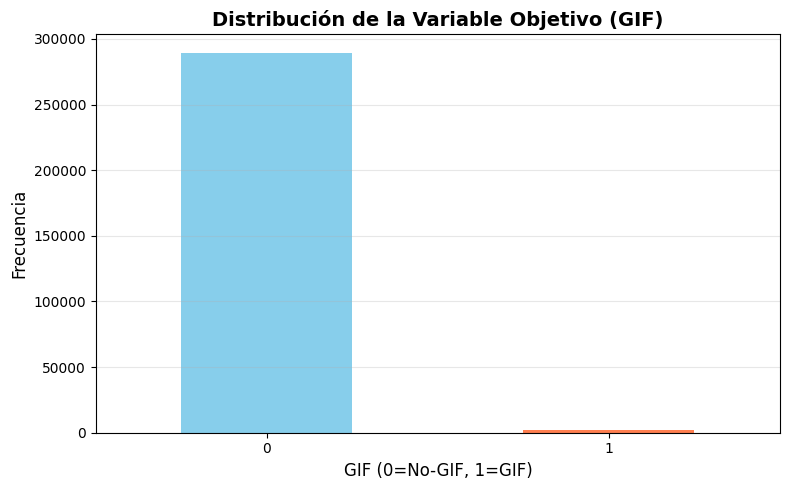

In [16]:
# Variable objetivo: GIF (superficie > 500 ha)
df_merged['GIF'] = (df_merged['superficie'] > 500).astype(int)

print("=" * 80)
print("VARIABLE OBJETIVO: GIF")
print("=" * 80)

print(f"\n📊 Distribución de clases:")
print(f"   No-GIF (superficie <= 500 ha): {len(df_merged[df_merged['GIF'] == 0]):,} ({100*len(df_merged[df_merged['GIF'] == 0])/len(df_merged):.2f}%)")
print(f"   GIF (superficie > 500 ha): {len(df_merged[df_merged['GIF'] == 1]):,} ({100*len(df_merged[df_merged['GIF'] == 1])/len(df_merged):.2f}%)")

ratio_desbalanceo = len(df_merged[df_merged['GIF'] == 0]) / len(df_merged[df_merged['GIF'] == 1]) if len(df_merged[df_merged['GIF'] == 1]) > 0 else float('inf')
print(f"\n⚠️  Ratio de desbalanceo: {ratio_desbalanceo:.1f}:1 (No-GIF:GIF)")

# Visualización de distribución
plt.figure(figsize=(8, 5))
df_merged['GIF'].value_counts().sort_index().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Distribución de la Variable Objetivo (GIF)', fontsize=14, fontweight='bold')
plt.xlabel('GIF (0=No-GIF, 1=GIF)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. SPLIT TEMPORAL

Realizamos el split temporal: Train (1968-2015) y Test (2016-2020).

**CRÍTICO:** Split por año, no aleatorio, para evitar data leakage.

In [17]:
# Split temporal
print("=" * 80)
print("SPLIT TEMPORAL")
print("=" * 80)

# Train: 1968-2015 (80%)
# Test: 2016-2020 (20%)
train_mask = df_merged['año'] <= 2015
test_mask = df_merged['año'] > 2015

df_train = df_merged[train_mask].copy()
df_test = df_merged[test_mask].copy()

print(f"\n📊 División de datos:")
print(f"   Train (1968-2015): {len(df_train):,} registros ({100*len(df_train)/len(df_merged):.1f}%)")
print(f"   Test (2016-2020): {len(df_test):,} registros ({100*len(df_test)/len(df_merged):.1f}%)")

print(f"\n📅 Rango de fechas:")
print(f"   Train: {df_train['fecha'].min()} a {df_train['fecha'].max()}")
print(f"   Test: {df_test['fecha'].min()} a {df_test['fecha'].max()}")

# Verificar que no hay solapamiento
años_train = set(df_train['año'].unique())
años_test = set(df_test['año'].unique())
solapamiento = años_train.intersection(años_test)

if len(solapamiento) == 0:
    print(f"\n✅ Verificación: No hay solapamiento entre train y test")
else:
    print(f"\n⚠️  ADVERTENCIA: Hay solapamiento en años: {solapamiento}")

# Distribución de GIF en train/test
print(f"\n📊 Distribución de GIF:")
print(f"   Train - No-GIF: {len(df_train[df_train['GIF'] == 0]):,} ({100*len(df_train[df_train['GIF'] == 0])/len(df_train):.2f}%)")
print(f"   Train - GIF: {len(df_train[df_train['GIF'] == 1]):,} ({100*len(df_train[df_train['GIF'] == 1])/len(df_train):.2f}%)")
print(f"   Test - No-GIF: {len(df_test[df_test['GIF'] == 0]):,} ({100*len(df_test[df_test['GIF'] == 0])/len(df_test):.2f}%)")
print(f"   Test - GIF: {len(df_test[df_test['GIF'] == 1]):,} ({100*len(df_test[df_test['GIF'] == 1])/len(df_test):.2f}%)")

SPLIT TEMPORAL

📊 División de datos:
   Train (1968-2015): 275,302 registros (94.6%)
   Test (2016-2020): 15,742 registros (5.4%)

📅 Rango de fechas:
   Train: 1968-01-01 00:00:00 a 2015-12-30 00:00:00
   Test: 2016-01-01 00:00:00 a 2020-12-28 00:00:00

✅ Verificación: No hay solapamiento entre train y test

📊 Distribución de GIF:
   Train - No-GIF: 273,448 (99.33%)
   Train - GIF: 1,854 (0.67%)
   Test - No-GIF: 15,629 (99.28%)
   Test - GIF: 113 (0.72%)


## 10. VERIFICACIÓN DE CALIDAD

Verificamos la calidad de los datos procesados antes de guardarlos.

In [18]:
# Verificación de calidad
print("=" * 80)
print("VERIFICACIÓN DE CALIDAD")
print("=" * 80)

# Contar nulos por columna
print("\n📊 Valores nulos por columna - Train:")
nulos_train = df_train.isnull().sum()
nulos_train_pct = (nulos_train / len(df_train) * 100).round(2)
df_nulos_train = pd.DataFrame({
    'Nulos': nulos_train,
    'Porcentaje': nulos_train_pct
})
df_nulos_train = df_nulos_train[df_nulos_train['Nulos'] > 0].sort_values('Nulos', ascending=False)
if len(df_nulos_train) > 0:
    print(df_nulos_train)
else:
    print("   ✅ No hay valores nulos")

print("\n📊 Valores nulos por columna - Test:")
nulos_test = df_test.isnull().sum()
nulos_test_pct = (nulos_test / len(df_test) * 100).round(2)
df_nulos_test = pd.DataFrame({
    'Nulos': nulos_test,
    'Porcentaje': nulos_test_pct
})
df_nulos_test = df_nulos_test[df_nulos_test['Nulos'] > 0].sort_values('Nulos', ascending=False)
if len(df_nulos_test) > 0:
    print(df_nulos_test)
else:
    print("   ✅ No hay valores nulos")

VERIFICACIÓN DE CALIDAD

📊 Valores nulos por columna - Train:
                 Nulos  Porcentaje
lat              54435       19.77
lng              54435       19.77
latlng_explicit  54393       19.76
region           31830       11.56

📊 Valores nulos por columna - Test:
        Nulos  Porcentaje
region   3247       20.63


In [19]:
# Verificar distribución GIF en train/test
print("\n📊 Verificación de distribución GIF:")
ratio_train = len(df_train[df_train['GIF'] == 0]) / len(df_train[df_train['GIF'] == 1]) if len(df_train[df_train['GIF'] == 1]) > 0 else float('inf')
ratio_test = len(df_test[df_test['GIF'] == 0]) / len(df_test[df_test['GIF'] == 1]) if len(df_test[df_test['GIF'] == 1]) > 0 else float('inf')

print(f"   Ratio Train: {ratio_train:.1f}:1")
print(f"   Ratio Test: {ratio_test:.1f}:1")

# Verificar que no hay fechas test en train
fechas_test = set(df_test['fecha'].dt.date)
fechas_train = set(df_train['fecha'].dt.date)
fechas_comunes = fechas_test.intersection(fechas_train)

if len(fechas_comunes) == 0:
    print(f"\n✅ Verificación: No hay fechas de test en train")
else:
    print(f"\n⚠️  ADVERTENCIA: Hay {len(fechas_comunes)} fechas comunes entre train y test")

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas - Train:")
print(df_train[['superficie', 'fwi_mean', 'fwi_max', 'fwi_p90']].describe())


📊 Verificación de distribución GIF:
   Ratio Train: 147.5:1
   Ratio Test: 138.3:1

✅ Verificación: No hay fechas de test en train

📊 Estadísticas descriptivas - Train:
       superficie  fwi_mean   fwi_max   fwi_p90
count   275302.00 275302.00 275302.00 275302.00
mean        26.65     18.97     27.18     24.53
std        225.08     14.73     17.95     17.08
min          1.00      0.00      0.00      0.00
25%          1.80      6.41     11.10      9.42
50%          3.50     15.91     25.95     22.58
75%         10.18     28.76     40.02     36.68
max      28879.10    102.79    119.42    116.99


## 11. GUARDAR DATASETS PROCESADOS

Guardamos los datasets procesados en formato CSV para su uso en el modelado.

In [20]:
# Seleccionar columnas finales para guardar
# Incluir todas las features creadas y variables originales relevantes
columnas_finales = [
    'id', 'fecha', 'superficie', 'idprovincia', 'idmunicipio', 'municipio',
    'fwi_mean', 'fwi_max', 'fwi_p90', 'fwi_cat',
    'mes', 'dia_semana', 'estacion', 'es_verano', 'año',
    'region', 'municipio_encoded',
    'GIF'
]

# Verificar que todas las columnas existen
columnas_disponibles = [col for col in columnas_finales if col in df_train.columns]
columnas_faltantes = [col for col in columnas_finales if col not in df_train.columns]

if columnas_faltantes:
    print(f"⚠️  Columnas faltantes: {columnas_faltantes}")
    print(f"✅ Usando columnas disponibles: {len(columnas_disponibles)}/{len(columnas_finales)}")

df_train_final = df_train[columnas_disponibles].copy()
df_test_final = df_test[columnas_disponibles].copy()

print(f"\n📊 Columnas finales ({len(columnas_disponibles)}):")
for i, col in enumerate(columnas_disponibles, 1):
    print(f"   {i}. {col}")


📊 Columnas finales (18):
   1. id
   2. fecha
   3. superficie
   4. idprovincia
   5. idmunicipio
   6. municipio
   7. fwi_mean
   8. fwi_max
   9. fwi_p90
   10. fwi_cat
   11. mes
   12. dia_semana
   13. estacion
   14. es_verano
   15. año
   16. region
   17. municipio_encoded
   18. GIF


In [21]:
# Guardar datasets procesados
print("\n" + "=" * 80)
print("GUARDANDO DATASETS PROCESADOS")
print("=" * 80)

train_path = processed_dir / 'train.csv'
test_path = processed_dir / 'test.csv'

print(f"\n💾 Guardando train.csv...")
df_train_final.to_csv(train_path, index=False)
print(f"   ✅ Guardado: {train_path}")
print(f"   📊 Registros: {len(df_train_final):,}")

print(f"\n💾 Guardando test.csv...")
df_test_final.to_csv(test_path, index=False)
print(f"   ✅ Guardado: {test_path}")
print(f"   📊 Registros: {len(df_test_final):,}")

print(f"\n✅ Preprocesamiento completado exitosamente!")
print(f"\n📁 Archivos guardados en: {processed_dir}")
print(f"   - train.csv ({len(df_train_final):,} registros)")
print(f"   - test.csv ({len(df_test_final):,} registros)")


GUARDANDO DATASETS PROCESADOS

💾 Guardando train.csv...
   ✅ Guardado: ../data/processed/train.csv
   📊 Registros: 275,302

💾 Guardando test.csv...
   ✅ Guardado: ../data/processed/test.csv
   📊 Registros: 15,742

✅ Preprocesamiento completado exitosamente!

📁 Archivos guardados en: ../data/processed
   - train.csv (275,302 registros)
   - test.csv (15,742 registros)


## Resumen del Preprocesamiento

### Transformaciones Aplicadas

1. **Filtrado temporal:** Excluidos años 2021-2023 (datos incompletos)
2. **Merge FWI:** 
   - Asignación de provincia a coordenadas FWI mediante distancia euclidiana
   - Agregación por (fecha, provincia) → fwi_mean, fwi_max, fwi_p90
   - Join con incendios y imputación de nulos
3. **Feature Engineering:**
   - Temporales: mes, dia_semana, estacion, es_verano, año
   - Geográficas: region, municipio_encoded
   - FWI: fwi_cat (categorizado)
4. **Variable objetivo:** GIF (superficie > 500 ha)
5. **Split temporal:** Train (1968-2015) / Test (2016-2020)

### Estadísticas Finales

- **Train:** [verificar en ejecución]
- **Test:** [verificar en ejecución]
- **Desbalanceo:** ~146:1 (No-GIF:GIF)
- **Features creadas:** [verificar en ejecución]

### Próximos Pasos

Los datasets procesados están listos para:
1. Análisis exploratorio adicional
2. Modelado (clasificación binaria)
3. Manejo de desbalanceo (SMOTE, undersampling, etc.)
4. Entrenamiento de modelos (Random Forest, XGBoost, etc.)